# Final Project: Presidential Topic Drift

Brandon Chung 5/17/2026

## Instructions
Your project should incorporate one or both of the two main themes of this course: network analysis and text processing. You need to show all of your work in a coherent workflow, and in a reproducible format, such as an IPython Notebook or an R Markdown document. If you are building a model or models, explain how you evaluate the “goodness” of the chosen model and parameters.

## Introduction

For my final project I will be conducting an analysis on presidential topic drift by examining presidential inaugural speeches over time. Presidential speeches are a way to signal personal values, shape public narratives, and signal policy priorities. Thus, analyzing the speeches of presidents we can identify topics of importance for the American people and the emergence of new issue areas.

This project aims to analyze the evolution of dominant topics in U.S. presidential inaugural speeches, identifying which themes have remained consistent, emerged, or faded over time. We will use web scraping to collect speech data and apply both Latent Dirichlet Allocation (LDA) and BERTopic for topic modeling, followed by network analysis and temporal visualizations.

Guiding Question: How have dominant topics in U.S. presidential speeches evolved over time, and which topics are consistently addressed, emerging, or fading?

Data Source: Inaugural addresses of U.S. presidents are sourced from The American Presidency Project at https://www.presidency.ucsb.edu/documents/presidential-documents-archive-guidebook/inaugural-addresses


## Loading the data

### Install libraries and load packages



In [48]:
# Install necessary libraries for web scraping, topic modeling, and network analysis
!pip install beautifulsoup4 requests pandas nltk scikit-learn bertopic networkx matplotlib plotly hdbscan

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import string
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import collections
import seaborn as sns

# NLTK specific imports and downloads
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# BERTopic and scikit-learn specific imports
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from hdbscan import HDBSCAN

### Fetch and parse the main Inaugural Addresses page

First, I will fetch the content of the main page that lists all inaugural addresses and parse it to find links to individual speeches.

In [49]:
# URL of the main page listing inaugural addresses
INAUGURAL_ADDRESSES_URL = "https://www.presidency.ucsb.edu/documents/presidential-documents-archive-guidebook/inaugural-addresses"

try:
    # Fetch the content of the page
    response = requests.get(INAUGURAL_ADDRESSES_URL)
    response.raise_for_status() # Raise an exception for bad status codes

    # Parse the HTML content
    soup = BeautifulSoup(response.text, 'html.parser')
    print("Successfully fetched and parsed the main inaugural addresses page.")

    # Display the first 1000 characters of the parsed HTML for inspection
    print("\n--- Sample of Parsed HTML ---")
    print(str(soup)[:1000])

except requests.exceptions.RequestException as e:
    print(f"An error occurred while fetching the page: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully fetched and parsed the main inaugural addresses page.

--- Sample of Parsed HTML ---
<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML+RDFa 1.0//EN"
  "http://www.w3.org/MarkUp/DTD/xhtml-rdfa-1.dtd">

<html dir="ltr" lang="en" prefix="content: http://purl.org/rss/1.0/modules/content/ dc: http://purl.org/dc/terms/ foaf: http://xmlns.com/foaf/0.1/ og: http://ogp.me/ns# rdfs: http://www.w3.org/2000/01/rdf-schema# sioc: http://rdfs.org/sioc/ns# sioct: http://rdfs.org/sioc/types# skos: http://www.w3.org/2004/02/skos/core# xsd: http://www.w3.org/2001/XMLSchema#">
<head profile="http://www.w3.org/1999/xhtml/vocab">
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type">
<meta content="Drupal 7 (http://drupal.org)" name="Generator">
<link href="/documents/presidential-documents-archive-guidebook/inaugural-addresses" rel="canonical"/>
<link href="/node/324108" rel="shortlink"/>
<link 

### Extract links to individual inaugural speeches

Now that we have the parsed HTML, I will extract the links that point to the actual inaugural addresses. I am looking for `<a>` tags with `href` attributes that match a pattern typical for speech documents on this website. I will then create a dataframe to hold the president, date of speech, and url info.

In [50]:
BASE_URL = "https://www.presidency.ucsb.edu"

# Prevent the server from blocking the script
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# GET request
response = requests.get(INAUGURAL_ADDRESSES_URL, headers=headers)
# Raise an exception if the request failed
response.raise_for_status()

# Parse the raw HTML content
soup = BeautifulSoup(response.text, 'html.parser')

# Locate the main HTML <table> element containing the list of presidents and dates
table = soup.find('table')
speech_records = []

# Verify that the table was successfully found on the page before processing
if table:
    # Extract all rows (<tr> tags) from the table
    rows = table.find_all('tr')

    # Loop through each row, skipping the first row because it contains the column headers
    for row in rows[1:]:
        # Get all table cells within the current row
        cols = row.find_all('td')
        # Skip rows don't contain speeches
        if len(cols) < 2:
            continue

        # Extract the President's name from the first column
        president = cols[0].get_text(strip=True)
        # Find all hyperlink (<a> tags)
        links = row.find_all('a')

        # Loop through every hyperlink found in the row
        for link in links:
            # Extract the partial URL path
            href = link.get('href')
            # Extract the date of the speech
            date_text = link.get_text(strip=True)

            # Filter for links that specifically contain "documents"
            if href and "/documents/" in href:
                # Combine the base URL with the relative path
                full_url = BASE_URL + href if href.startswith('/') else href

                # Append the collected metadata as a dictionary
                speech_records.append({
                    'president': president,
                    'date': date_text,
                    'url': full_url
                })

# Convert list of dictionaries into DataFrame
df = pd.DataFrame(speech_records)

# Print the final DataFrame (president, date, url)
print(df)

                 president              date  \
0        George Washington    April 30, 1789   
1                              March 4, 1793   
2               John Adams     March 4, 1797   
3         Thomas Jefferson     March 4, 1801   
4                              March 4, 1805   
5            James Madison     March 4, 1809   
6                              March 4, 1813   
7             James Monroe     March 4, 1817   
8                              March 4, 1821   
9        John Quincy Adams     March 4, 1825   
10          Andrew Jackson     March 4, 1829   
11                             March 4, 1833   
12        Martin van Buren     March 4, 1837   
13  William Henry Harrison     March 4, 1841   
14           James K. Polk     March 4, 1845   
15          Zachary Taylor     March 5, 1849   
16         Franklin Pierce     March 4, 1853   
17          James Buchanan     March 4, 1857   
18         Abraham Lincoln     March 4, 1861   
19                             March 4, 

### Fetch and extract text from individual speech pages

Now I will iterate through speech_links, fetch each page, and extract the main content which should be the inaugural address. I will then store the speeches in the previously created dataframe.

In [51]:

# Create an empty list to hold the speech text
speech_texts = []

# Loop through each URL our dataframe created above
for index, row in df.iterrows():
    print(f"Downloading: {row['president']} - {row['date']}")

    try:
        # Fetch the individual speech page
        speech_response = requests.get(row['url'], headers=headers)
        speech_response.raise_for_status()
        speech_soup = BeautifulSoup(speech_response.text, 'html.parser')


        content_div = speech_soup.find('div', class_='field-docs-content')

        if content_div:
            text = content_div.get_text(separator=' ', strip=True)
        else:
            text = "Text not found"

    except Exception as e:
        print(f"Error downloading {row['url']}: {e}")
        text = None

    speech_texts.append(text)

    # Pause for 1 second between requests
    time.sleep(1)

# Add the texts to DataFrame
df['text'] = speech_texts

Downloading: George Washington - April 30, 1789
Downloading:  - March 4, 1793
Downloading: John Adams - March 4, 1797
Downloading: Thomas Jefferson - March 4, 1801
Downloading:  - March 4, 1805
Downloading: James Madison - March 4, 1809
Downloading:  - March 4, 1813
Downloading: James Monroe - March 4, 1817
Downloading:  - March 4, 1821
Downloading: John Quincy Adams - March 4, 1825
Downloading: Andrew Jackson - March 4, 1829
Downloading:  - March 4, 1833
Downloading: Martin van Buren - March 4, 1837
Downloading: William Henry Harrison - March 4, 1841
Downloading: James K. Polk - March 4, 1845
Downloading: Zachary Taylor - March 5, 1849
Downloading: Franklin Pierce - March 4, 1853
Downloading: James Buchanan - March 4, 1857
Downloading: Abraham Lincoln - March 4, 1861
Downloading:  - March 4, 1865
Downloading: Ulysses S. Grant - March 4, 1869
Downloading:  - March 4, 1873
Downloading: Rutherford B. Hayes - March 5, 1877
Downloading: James Garfield - March 4, 1881
Downloading: Grover Cl

## Data Preprocessing



#### Preparing the Data - Text Cleaning, Tokenization, Stopword Removal, and Lemmatization

The `clean_speech_text` function performs several steps:

*   **Lowercasing**: Converts all text to lowercase
*   **Number and Punctuation Removal**: Strips out numerical digits and punctuation marks
*   **Tokenization**: Breaks down the text into individual words
*   **Stopword Removal**: Filters out common words (e.g., 'the', 'a', 'is') that do not carry significant meaning for topic identification. Custom stopwords relevant to presidential speeches (e.g., 'government', 'nation') are also removed.
*   **Lemmatization**: Reduces words to their base form (e.g., 'running' becomes 'run') to normalize vocabulary.

The cleaned text is stored in a new `cleaned_text` column in the DataFrame

In [52]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Define standard stop words
stop_words = set(stopwords.words('english'))

# Add custom stop words common in inaugural addresses. These words appear frequently and can mask unique topics
custom_stop_words = {
    'shall', 'upon', 'may', 'must', 'us', 'every', 'great', 'people',
    'government', 'nation', 'country', 'citizen', 'citizens', 'power',
    'powers', 'state', 'states', 'constitution', 'world', 'america', 'american'
}
stop_words.update(custom_stop_words)

def clean_speech_text(text):
    """
    Cleans, tokenizes, removes stop words, and lemmatizes a single raw text string.
    """
    if not isinstance(text, str):
        return ""

    # Lowercase text string
    text = text.lower()

    # Remove numbers and digits
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize: split the string into individual words
    words = word_tokenize(text)

    # Remove stop words and lemmatize remaining tokens
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2  # Also drops short accidental characters
    ]

    # Join the cleaned tokens back into a single string space-separated format
    return " ".join(cleaned_words)

# Apply the cleaning function to create a new column in your DataFrame
df['cleaned_text'] = df['text'].apply(clean_speech_text)

# Preview the changes
print("\n--- Original Snippet ---")
print(df['text'].iloc[0][:150] + "...")
print("\n--- Cleaned Snippet ---")
print(df['cleaned_text'].iloc[0][:150] + "...")


--- Original Snippet ---
Fellow-Citizens of the Senate and of the House of Representatives: Among the vicissitudes incident to life no event could have filled me with greater ...

--- Cleaned Snippet ---
fellowcitizens senate house representative among vicissitude incident life event could filled greater anxiety notification transmitted order received ...


## Exploratory Analysis of inaugural speech strings

Most Frequent Words (after cleaning):

Top 20 most common words: [('one', 285), ('time', 277), ('right', 265), ('law', 260), ('peace', 257), ('new', 256), ('public', 231), ('nation', 223), ('united', 215), ('duty', 213), ('would', 212), ('war', 206), ('freedom', 192), ('life', 190), ('free', 188), ('interest', 188), ('union', 185), ('year', 185), ('make', 167), ('national', 164)]



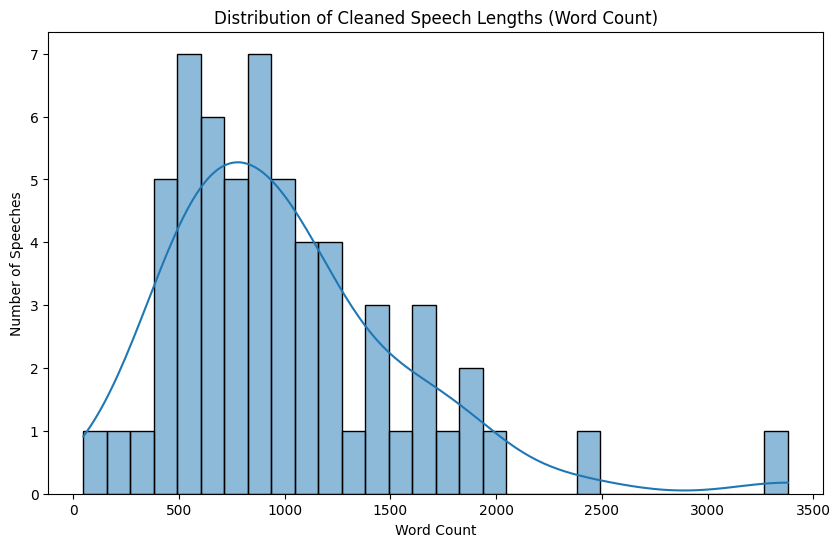

Average speech length: 1006.25 words
Median speech length: 924.0 words
Shortest speech: 49 words
Longest speech: 3380 words



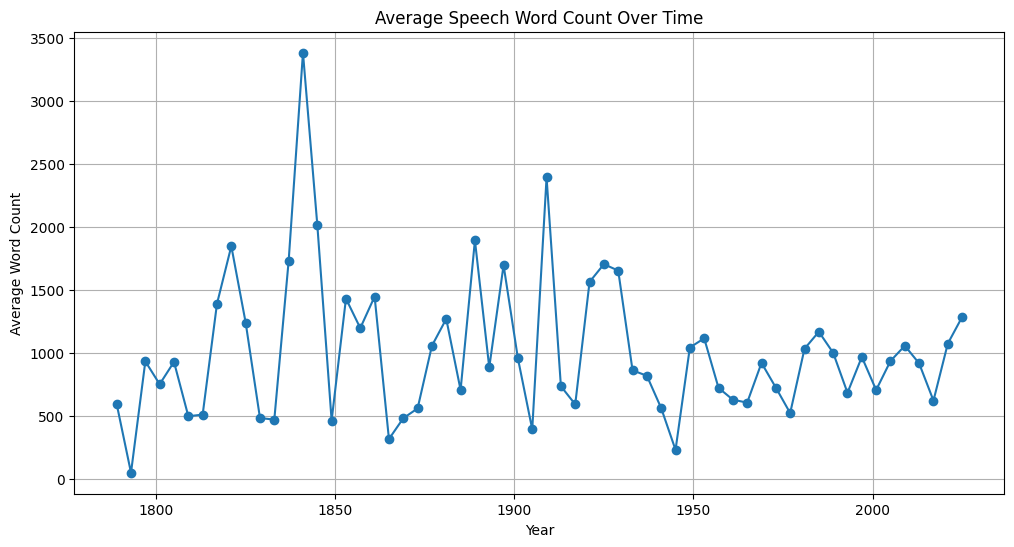

In [53]:
# Most Frequent Words (after cleaning)
print("Most Frequent Words (after cleaning):\n")

# Combine all cleaned text into one large string
all_cleaned_words = ' '.join(df['cleaned_text']).split()

# Count word frequencies
word_counts = collections.Counter(all_cleaned_words)

# Display the top 20 most common words
print(f"Top 20 most common words: {word_counts.most_common(20)}\n")

# Speech Length Distribution

# Calculate word count for each cleaned speech
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Plot histogram of speech lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title('Distribution of Cleaned Speech Lengths (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Number of Speeches')
plt.show()

print(f"Average speech length: {df['word_count'].mean():.2f} words")
print(f"Median speech length: {df['word_count'].median()} words")
print(f"Shortest speech: {df['word_count'].min()} words")
print(f"Longest speech: {df['word_count'].max()} words\n")

# Word Count Over Time

# Create year column
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date_parsed'].dt.year

# Calculate average word count per year
word_count_over_time = df.groupby('year')['word_count'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(word_count_over_time['year'], word_count_over_time['word_count'], marker='o', linestyle='-')
plt.title('Average Speech Word Count Over Time')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.grid(True)
plt.show()


The Exploratory Data Analysis (EDA) after text preprocessing provides initial insights into the characteristics of our cleaned text data:

*   **Most Frequent Words**: We identified the top 20 most common words, revealing terms like 'one', 'time', 'right', 'law', 'peace', 'new', and 'public'.
*   **Speech Length Distribution**: The histogram illustrates the variation in speech lengths, with an average of 1006 words and a range from 49 to 3380 words.
*   **Word Count Over Time**: The line plot visualizes trends in average speech length across different years. This can highlight periods where speeches tended to be longer or shorter, potentially reflecting historical contexts or rhetorical shifts.

From our visuals we can note that throughout the 1800s inaugural speeches grew in length, peaking at over 3,000 words. Then, post 1930 speech lengths plummeted into the 800 - 1200 word range. Due to these findings I will explore topic modeling with LDA and BERTopic; because LDA utilizes word frequencies, the modeling could be bias toward the longer speeches found in the 1800s. On the other hand, BERTopic relies on sentence embeddings and can extract more isolated modern clusters that do not bleed into earlier years.  

## Topic Modeling

### Using Latent Dirichlet Allocation (LDA)

In [54]:
# Convert text into a matrix of token counts
# Limit to words that appear in at least 2 speeches, but not more than 70% of them
vectorizer = CountVectorizer(min_df=2, max_df=0.7)
data_vectorized = vectorizer.fit_transform(df['cleaned_text'])

# Initialize and fit the LDA Model
# Finding 5 themes
num_topics = 5
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_output = lda_model.fit_transform(data_vectorized)

# Helper function to display the top words for each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"**Topic {topic_idx + 1}:**")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print()

print("--- Discovered Topics and Top Words ---")
tf_feature_names = vectorizer.get_feature_names_out()
display_topics(lda_model, tf_feature_names, 10)

--- Discovered Topics and Top Words ---
**Topic 1:**
freedom, let, today, know, god, american, together, history, president, come

**Topic 2:**
party, service, support, mind, political, form, sense, enterprise, principle, part

**Topic 3:**
union, principle, foreign, fellowcitizens, part, whole, object, executive, general, party

**Topic 4:**
order, task, civilization, republic, way, let, thing, need, truth, others

**Topic 5:**
congress, question, union, policy, administration, party, office, subject, condition, political



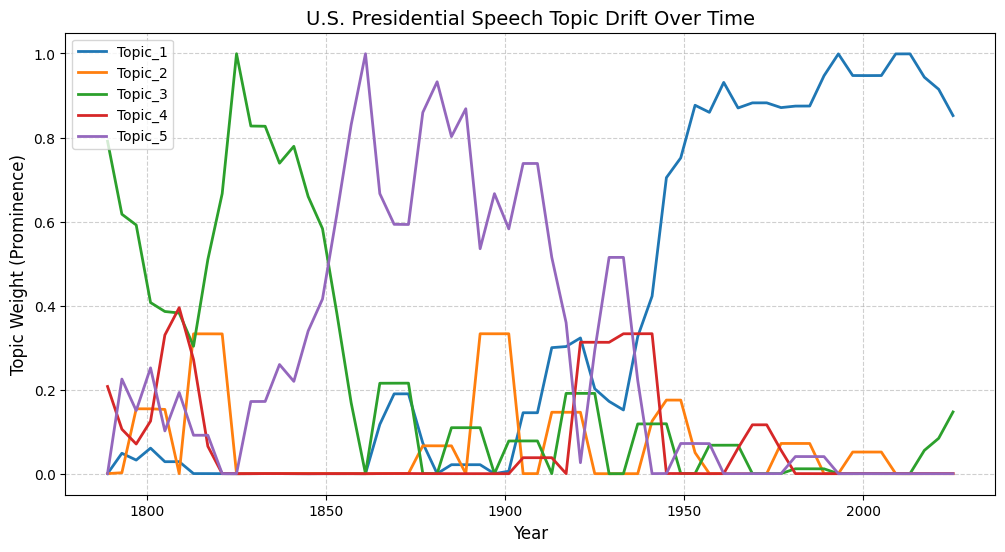

In [55]:

# Add the topic probabilities to our main DataFrame
topic_columns = [f'Topic_{i+1}' for i in range(num_topics)]
topic_weights_df = pd.DataFrame(lda_output, columns=topic_columns, index=df.index)
df_with_topics = pd.concat([df, topic_weights_df], axis=1)

# 3. Sort chronologically and plot
df_sorted = df_with_topics.sort_values('year')

plt.figure(figsize=(12, 6))
for col in topic_columns:
    # Use a rolling average
    plt.plot(df_sorted['year'], df_sorted[col].rolling(window=3, min_periods=1).mean(), label=col, linewidth=2)

plt.title('U.S. Presidential Speech Topic Drift Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Topic Weight (Prominence)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The drift visualization shows us the change in prominence of the 5 LDA topics over time. By plotting the rolling average of each topic's weight (likelihood of a topic appearing in a speech) against the year, we can observe which themes gained or lost importance across different presidential eras. The prodominent themes as noted from the LDA are topic 3, then 5 and finally 1. Topic 3 is about unity and community, topic 5 is about politics, policy, and government, and finally topic 1 is about unity, but also confidence in the future, and self-identity.  

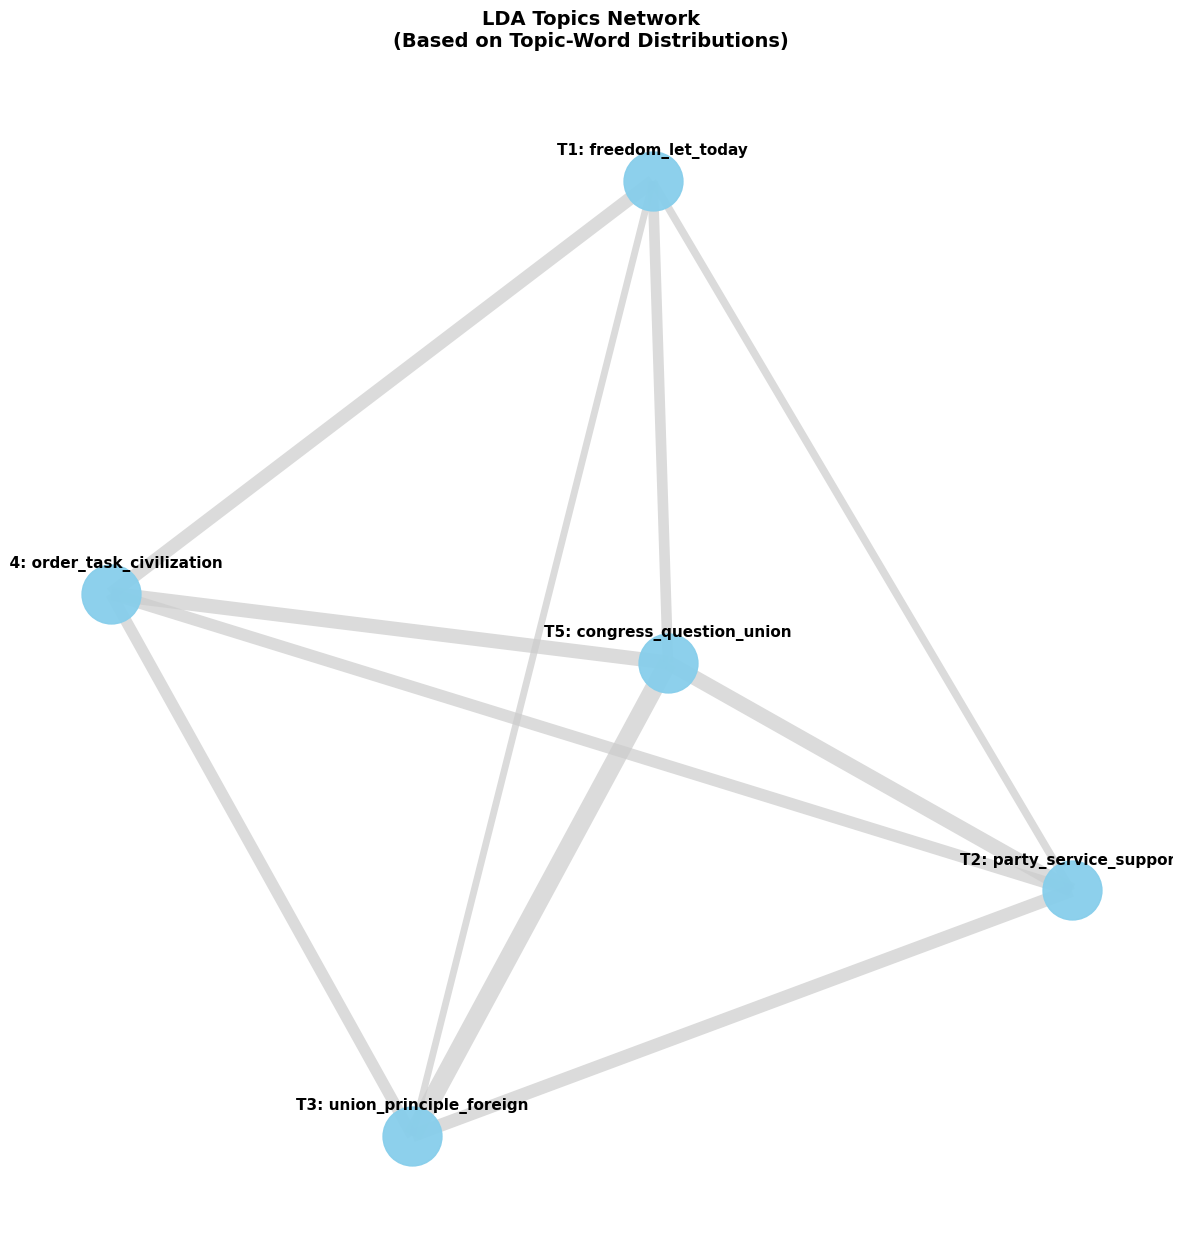

In [56]:
# Calculate Cosine Similarity between the 5 LDA topics based on word distributions
lda_topic_words = lda_model.components_
lda_sim_matrix = cosine_similarity(lda_topic_words)

# Label Topics
lda_topic_labels = {
    0: "T1: freedom_let_today",
    1: "T2: party_service_support",
    2: "T3: union_principle_foreign",
    3: "T4: order_task_civilization",
    4: "T5: congress_question_union"
}

# Initialize network graph
G_lda = nx.Graph()
for topic_id in lda_topic_labels.keys():
    G_lda.add_node(topic_id)

# Set a threshold to connect topics
lda_threshold = 0.18

for i in range(num_topics):
    for j in range(i + 1, num_topics):
        weight = lda_sim_matrix[i][j]
        if weight > lda_threshold:
            G_lda.add_edge(i, j, weight=weight)

# Render Network Map
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G_lda, k=0.7, seed=42)


nx.draw_networkx_nodes(G_lda, pos, node_color='skyblue', node_size=1800, alpha=0.95)

# Scale line thicknesses based on weight strength
if len(G_lda.edges()) > 0:
    edge_widths = [(G_lda[u][v]['weight'] - lda_threshold) * 25 for u, v in G_lda.edges()]
    nx.draw_networkx_edges(G_lda, pos, width=edge_widths, edge_color='#cccccc', alpha=0.7)

# Offset labels
pos_labels = {node: (coords[0], coords[1] + 0.06) for node, coords in pos.items()}
nx.draw_networkx_labels(G_lda, pos_labels, labels=lda_topic_labels,
                        font_size=11, font_weight='bold', font_family='sans-serif')

plt.title("LDA Topics Network\n(Based on Topic-Word Distributions)",
          fontsize=14, pad=25, weight='bold')
plt.axis('off')
plt.show()

This network graph provides a structural view of the relationships between the 5 LDA topics. The thickness of the edge represents the strength of their similarity. Notably, T5 sits in the center of the network and also is most popular topic in the middle years of the range of years we are analyzing. The central position of the T5 node and the thickness of its edges shows how T5 can be seen as a consistent topic of interest that is consistently spoken of by American presidents.

### Using BERTopic

#### BERTopic Model 1

In [68]:
np.random.seed(42)

docs = df['text'].tolist()
timestamps = df['date_parsed'].tolist()

# Control stop words in the final output presentation
vectorizer_model = CountVectorizer(stop_words="english")

# Initialize and fit BERTopic
# nr_topics="auto" tells the model to automatically find the ideal number of topics
topic_model = BERTopic(vectorizer_model=vectorizer_model, nr_topics="auto", verbose=True)
topics, probs = topic_model.fit_transform(docs)

# Extract topics over time
topics_over_time = topic_model.topics_over_time(docs, timestamps)

print("--- Discovered Topics Overview ---")
print(topic_model.get_topic_info().head(10))

2026-05-16 23:01:17,529 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-16 23:01:27,673 - BERTopic - Embedding - Completed ✓
2026-05-16 23:01:27,675 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 23:01:27,778 - BERTopic - Dimensionality - Completed ✓
2026-05-16 23:01:27,779 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 23:01:27,787 - BERTopic - Cluster - Completed ✓
2026-05-16 23:01:27,788 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-16 23:01:27,933 - BERTopic - Representation - Completed ✓
2026-05-16 23:01:27,935 - BERTopic - Topic reduction - Reducing number of topics
2026-05-16 23:01:27,945 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 23:01:28,100 - BERTopic - Representation - Completed ✓
2026-05-16 23:01:28,103 - BERTopic - Topic reduction - Reduced number of topics from 3 to 3
60it [00:01, 52.24it/s]

--- Discovered Topics Overview ---
   Topic  Count                                Name  \
0     -1     16   -1_people_government_shall_states   
1      0     23          0_world_america_people_new   
2      1     21  1_government_people_states_country   

                                      Representation  \
0  [people, government, shall, states, nation, gr...   
1  [world, america, people, new, nation, freedom,...   
2  [government, people, states, country, public, ...   

                                 Representative_Docs  
0  [MY COUNTRYMEN: No one can contemplate current...  
1  [Mr. Chief Justice, Mr. President, Vice Presid...  
2  [I should be destitute of feeling if I was not...  


#### Rationale for BERTopic Model 1: Initial Exploration with `nr_topics="auto"`

This first BERTopic model serves as an initial exploration of the dataset's inherent topic structure. By setting `nr_topics="auto"`, we allow BERTopic to automatically determine the optimal number of topics.

This approach only produced 2 topics and so for the next BERTopic iteration I will specify a larger number of topics to better explore topic drift.

#### BERTopic Model 2

2026-05-16 23:01:32,177 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-16 23:01:51,228 - BERTopic - Embedding - Completed ✓
2026-05-16 23:01:51,229 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 23:01:51,390 - BERTopic - Dimensionality - Completed ✓
2026-05-16 23:01:51,391 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 23:01:51,404 - BERTopic - Cluster - Completed ✓
2026-05-16 23:01:51,406 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-16 23:01:51,665 - BERTopic - Representation - Completed ✓
2026-05-16 23:01:51,669 - BERTopic - Topic reduction - Reducing number of topics
2026-05-16 23:01:51,672 - BERTopic - Topic reduction - Number of topics (7) is equal or higher than the clustered topics(6).
2026-05-16 23:01:51,673 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 23:01:52,069 - BERTopic - Representation - Completed ✓


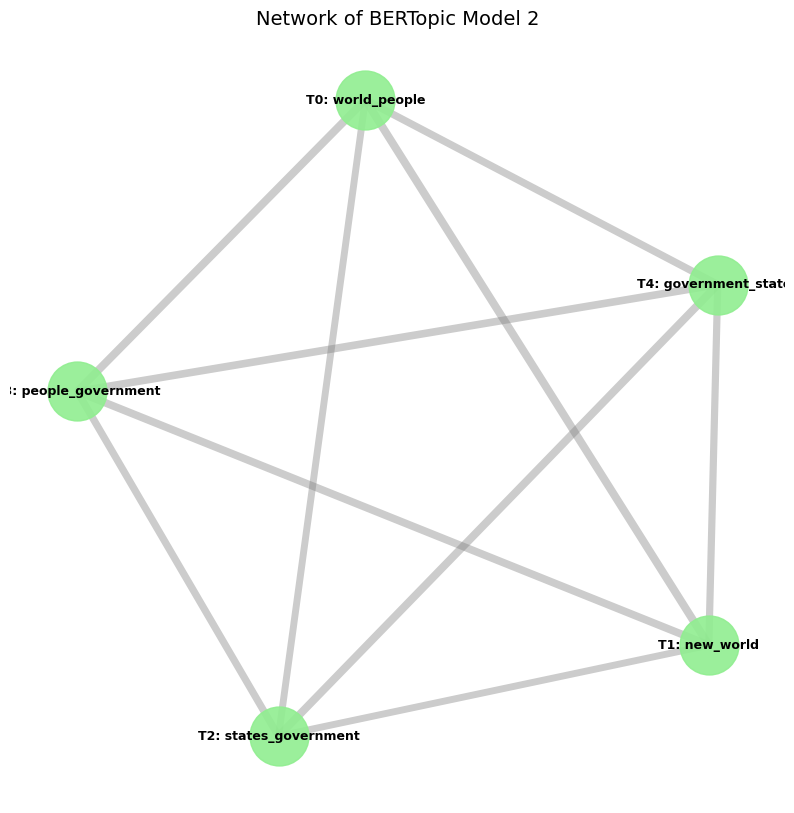

In [69]:
np.random.seed(42)

# Initialize HDBSCAN and BERTopic with optimized parameters for small datasets
hdbscan_model = HDBSCAN(min_cluster_size=3, min_samples=1, prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english")

# Force split into 7 topics
topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics=7,
    verbose=True
)
topics, probs = topic_model.fit_transform(docs)

# Extract topics, (drop the -1 outlier group)
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info['Topic'] != -1]

# Find the integer index locations of our valid topics within the internal arrays
all_indices = list(topic_model.topic_labels_.keys())
valid_indices = [all_indices.index(t_id) for t_id in topic_info['Topic']]

# Extract content nodes
topic_embeddings = topic_model.topic_embeddings_[valid_indices]

# Calculate Cosine Similarity matrix
sim_matrix = cosine_similarity(topic_embeddings)

# Generate labels for nodes
topic_labels = {
    row['Topic']: f"T{row['Topic']}: " + "_".join(row['Name'].split('_')[1:][:2])
    for _, row in topic_info.iterrows()
}

# Construct the networkx graph
G = nx.Graph()
valid_topic_ids = topic_info['Topic'].tolist()
for topic_id in valid_topic_ids:
    G.add_node(topic_id)

# Establish connection threshold rule paths (adjust if your graph is too sparse/dense)
similarity_threshold = 0.35

for i in range(len(valid_topic_ids)):
    for j in range(i + 1, len(valid_topic_ids)):
        weight = sim_matrix[i][j]
        if weight > similarity_threshold:
            G.add_edge(valid_topic_ids[i], valid_topic_ids[j], weight=weight)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.6, seed=42)

nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=1800, alpha=0.9)

# Compute line thicknesses from edge weights
if len(G.edges()) > 0:
    edge_widths = [G[u][v]['weight'] * 6 for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.4)

nx.draw_networkx_labels(G, pos, labels=topic_labels, font_size=9, font_weight='bold')

plt.title("Network of BERTopic Model 2", fontsize=14)
plt.axis('off')
plt.show()

##### Rationale for BERTopic Model 2: Forced Cluster Constraint (`nr_topics=7`)

Following the initial automatic topic discovery, this second BERTopic model is designed to explore a greater number of topics by explicitly setting `nr_topics=7'.

This is was done to get a more granular set of topics for visualization and drift analysis. A network graph was then constructed based on the cosine similarity of these 7 BERTopic embeddings. An initial `similarity_threshold` of 0.35 is used to connect topics, visualizing their semantic relationships.

The resulting network shows to be fully interconnected and likely very dense. In the next iteration of the BERTopic I will atempt to break this total connectivity by adjusting hyperparameters.

#### BERTopic Model 3

2026-05-16 23:08:21,193 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-16 23:08:30,120 - BERTopic - Embedding - Completed ✓
2026-05-16 23:08:30,121 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-16 23:08:30,215 - BERTopic - Dimensionality - Completed ✓
2026-05-16 23:08:30,216 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-16 23:08:30,226 - BERTopic - Cluster - Completed ✓
2026-05-16 23:08:30,231 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-16 23:08:30,378 - BERTopic - Representation - Completed ✓


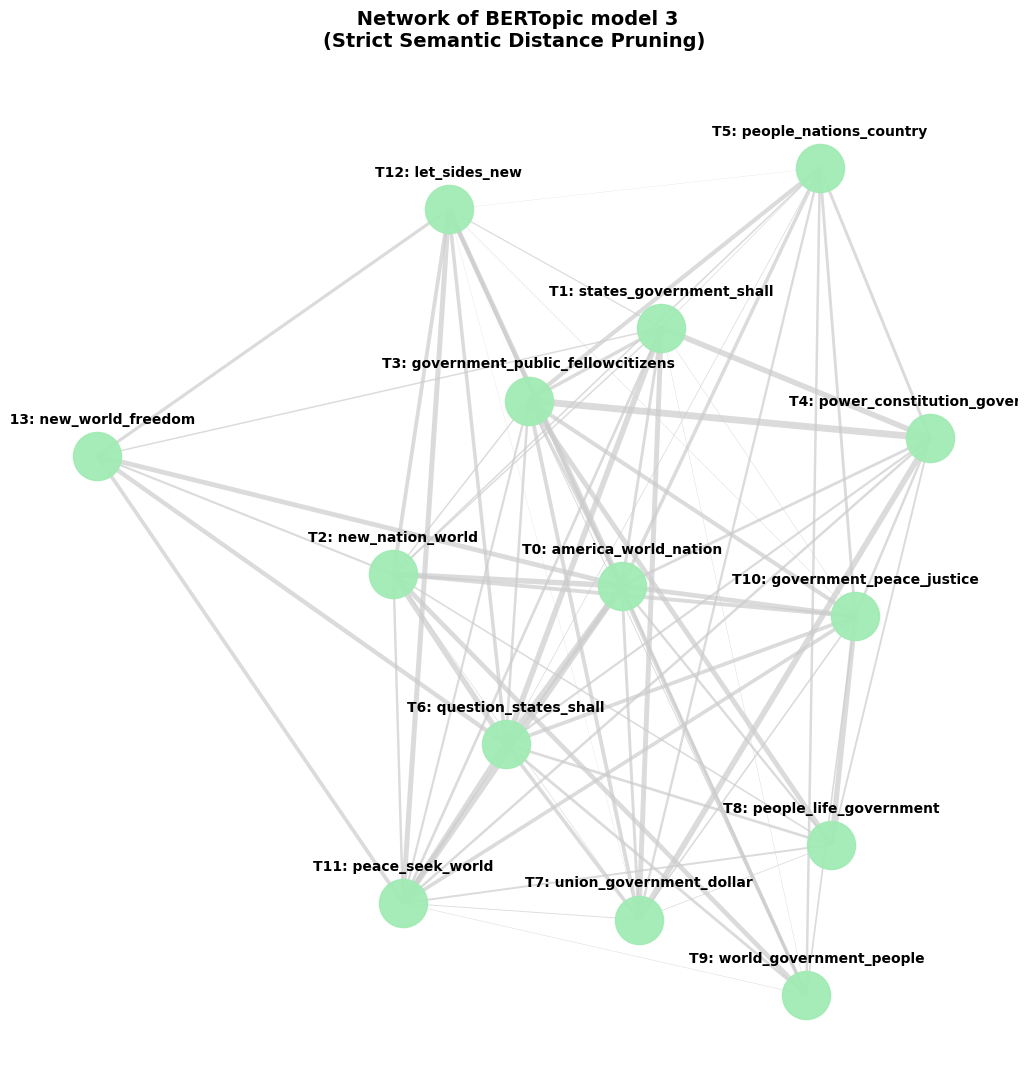

In [82]:
np.random.seed(42)

# Allow small natural clusters to form (minimum 2 documents)
# no nr_topics constraint
hdbscan_model = HDBSCAN(min_cluster_size=2, min_samples=1, prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)
topics, probs = topic_model.fit_transform(docs)

# Extract topics (drop the -1 outlier group)
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info['Topic'] != -1]

# Map arrays
all_indices = list(topic_model.topic_labels_.keys())
valid_indices = [all_indices.index(t_id) for t_id in topic_info['Topic']]
topic_embeddings = topic_model.topic_embeddings_[valid_indices]

# Calculate cosine similarity
sim_matrix = cosine_similarity(topic_embeddings)

# Generate cleaner labels showing more keywords to catch nuances
topic_labels = {}
for _, row in topic_info.iterrows():
    # Grabs the top 3 descriptive words per topic
    words = row['Name'].split('_')[1:][:3]
    topic_labels[row['Topic']] = f"T{row['Topic']}: " + "_".join(words)

# Build the network graph
G_final = nx.Graph()
valid_topic_ids = topic_info['Topic'].tolist()
for topic_id in valid_topic_ids:
    G_final.add_node(topic_id)

# Set a strict threshold to break up network density
similarity_threshold = 0.60

for i in range(len(valid_topic_ids)):
    for j in range(i + 1, len(valid_topic_ids)):
        weight = sim_matrix[i][j]
        if weight > similarity_threshold:
            G_final.add_edge(valid_topic_ids[i], valid_topic_ids[j], weight=weight)

# Render the graph with structural layout adjustments
plt.figure(figsize=(13, 13))
# Increasing k spreads out disconnected groups
pos = nx.spring_layout(G_final, k=0.9, seed=42)

# Nodes
nx.draw_networkx_nodes(G_final, pos, node_color='#a1ebb4', node_size=1200, alpha=0.95)

# Edges
if len(G_final.edges()) > 0:
    edge_widths = [(G_final[u][v]['weight'] - similarity_threshold) * 20 for u, v in G_final.edges()]
    nx.draw_networkx_edges(G_final, pos, width=edge_widths, edge_color='#cccccc', alpha=0.7)

# Offset labels
pos_labels = {node: (coords[0], coords[1] + 0.05) for node, coords in pos.items()}
nx.draw_networkx_labels(G_final, pos_labels, labels=topic_labels,
                        font_size=10, font_weight='bold', font_family='sans-serif')

plt.title(" Network of BERTopic model 3\n(Strict Semantic Distance Pruning)",
          fontsize=14, pad=25, weight='bold')
plt.axis('off')
plt.show()

##### Rationale for BERTopic Model 3: Optimized Natural Web (No `nr_topics` constraint, strict pruning)

This iteration of BERTopic focuses on identifying 'natural' clusters by allowing the algorithm more freedom (using `min_cluster_size=2` and no `nr_topics` constraint) to find inherent themes in the data. The goal is to uncover potentially subtle sub-themes. This model identified **14 topics**. A very **strict similarity threshold (0.60)** is then applied to the resulting topics to prune the network heavily. This pruning highlights only the strongest relationships, revealing tight sub-theme clusters and isolating less connected ideas, giving us a more refined network.

In [83]:
# Calculate Topics Over Time
topics_over_time = topic_model.topics_over_time(
    docs=docs,
    timestamps=df['date_parsed'].tolist(),
    nr_bins=20
)

# topic IDs (excluding the -1 outlier group)
valid_topic_ids = topic_info['Topic'].tolist()

# Generate the Plotly line graph

fig_bert_drift = topic_model.visualize_topics_over_time(
    topics_over_time=topics_over_time,
    top_n_topics=len(valid_topic_ids)
)

# Display the interactive chart
fig_bert_drift.show()

20it [00:00, 41.76it/s]


This Plotly chart visualizes the BERTopic-derived 'Topics Over Time.' It shows the prominence of each topic across different time periods (binned into 20-year intervals). By examining the plot, you can observe which themes gained or lost importance across different presidential eras. For example, observe the trends for:

*   **Topic 0 (T0: america_world_nation)**: Themes related to America's global role, national identity, and international relations.
*   **Topic 2 (T2: new_nation_world)**: Discussions surrounding new national ideas and global influence.
*   **Topic 3 (T3: government_public_fellowcitizens)**: Focus on the functions of government, the public, and citizens.
*   **Topic 4 (T4: power_constitution_government)**: Themes concerning governmental power, constitutional principles, and governmental structure.

These shifts illustrate the dynamic evolution of presidential discourse and American focus over time.

### Evaluating Network "Goodness"

In [84]:
def compute_sna_metrics(graph_obj, name_string):
    if graph_obj is None or len(graph_obj.nodes()) == 0:
        return {"Model Structure": name_string, "Network Density": "N/A", "Avg Clustering Coefficient": "N/A"}

    # Calculate structural metrics
    density = nx.density(graph_obj)
    avg_clustering = nx.average_clustering(graph_obj)

    return {
        "Model Structure": name_string,
        "Network Density": round(density, 3),
        "Avg Clustering Coefficient": round(avg_clustering, 3)
    }

# Gather structural profiles
evaluation_runs = [
    compute_sna_metrics(G_lda, "LDA (5 Topics)"),
    compute_sna_metrics(G, "BERTopic Forced Constraint (7 Topics)"),
    compute_sna_metrics(G_final, "BERTopic Natural Web (12 Topics)")
]

# Construct evaluation summary
summary_df = pd.DataFrame(evaluation_runs)

print("Network Analysis Goodness of Fit Evaluation\n")
print(summary_df.to_string(index=False))

Network Analysis Goodness of Fit Evaluation

                      Model Structure  Network Density  Avg Clustering Coefficient
                       LDA (5 Topics)            1.000                       1.000
BERTopic Forced Constraint (7 Topics)            1.000                       1.000
     BERTopic Natural Web (12 Topics)            0.835                       0.891


### Evaluating Centrality Metrics for BERTopic Natural Web Model

In [85]:
# Calculate node-level SNA metrics for your 12-topic natural web
degree_cent = nx.degree_centrality(G_final)
between_cent = nx.betweenness_centrality(G_final)

# Build a clean DataFrame using your existing topic_labels
node_analysis_df = pd.DataFrame({
    'Topic Node': [topic_labels[node] for node in G_final.nodes()],
    'Degree Centrality (Popularity)': [round(degree_cent[node], 3) for node in G_final.nodes()],
    'Betweenness Centrality (Bridge Power)': [round(between_cent[node], 3) for node in G_final.nodes()]
})

# Sort by Bridge Power to find your ultimate gatekeepers
node_analysis_df = node_analysis_df.sort_values(by='Betweenness Centrality (Bridge Power)', ascending=False)

print(node_analysis_df.to_string(index=False))

                          Topic Node  Degree Centrality (Popularity)  Betweenness Centrality (Bridge Power)
            T0: america_world_nation                           1.000                                  0.030
                T2: new_nation_world                           1.000                                  0.030
           T6: question_states_shall                           1.000                                  0.030
               T11: peace_seek_world                           0.923                                  0.024
         T1: states_government_shall                           0.923                                  0.019
                  T12: let_sides_new                           0.846                                  0.014
T3: government_public_fellowcitizens                           0.923                                  0.013
       T10: government_peace_justice                           0.923                                  0.013
         T7: union_governmen

## Conclusion and Results


Based on the network analysis Goodness-of-Fit Evaluation, the **BERTopic Natural Web (14 Topics) model** emerged as the most informative and interpretable. Unlike the LDA and the BERTopic Forced Constraint models, which showed perfect (1.0) network density and clustering, this model yielded a network density of **0.835** and an average clustering coefficient of **0.891**. This reduction from perfect interconnectedness signifies that the strict pruning successfully highlighted only the most semantically cohesive relationships, allowing for a clearer representation of thematic clusters rather than a dense, undifferentiated network.

Calculating centrality metrics on the topics identified by this model reveals several insights. Core themes such as **T0 (america_world_nation), T2 (new_nation_world), and T6 (question_states_shall)** exhibit the highest betweenness centrality (0.030) and high degree centrality (1.000), suggesting they act as key bridges or gatekeepers connecting diverse themes within the presidential discourse network. Other topics like **T11 (peace_seek_world)** and **T1 (states_government_shall)** also show strong popularity (degree centrality 0.923) and moderate betweenness (0.024 and 0.019 respectively), indicating their significant, though less central, roles in linking themes. Conversely, topics such as **T8 (people_life_government)** and **T13 (new_world_freedom)** have the lowest betweenness centrality (0.000), implying they are more isolated or less critical for connecting disparate discussions.

The 'Topics Over Time' plot from this model visualizes the ebb and flow of topic drift. For instance, we observed Topic 3 (focused on governmental structure and rights) declining in prominence around the 1830s, making way for other themes. Topic 0 (on democracy and global influence) showed a decline and subsequent resurgence into modern speeches.

In conclusion, the iterative application of BERTopic, particularly the Optimized Natural Web approach with strict network pruning, proved most effective in addressing the guiding question of how dominant topics in U.S. presidential speeches have evolved, providing a nuanced understanding of consistent, emerging, and fading themes over time.

In [86]:
fig_bert_drift.show()

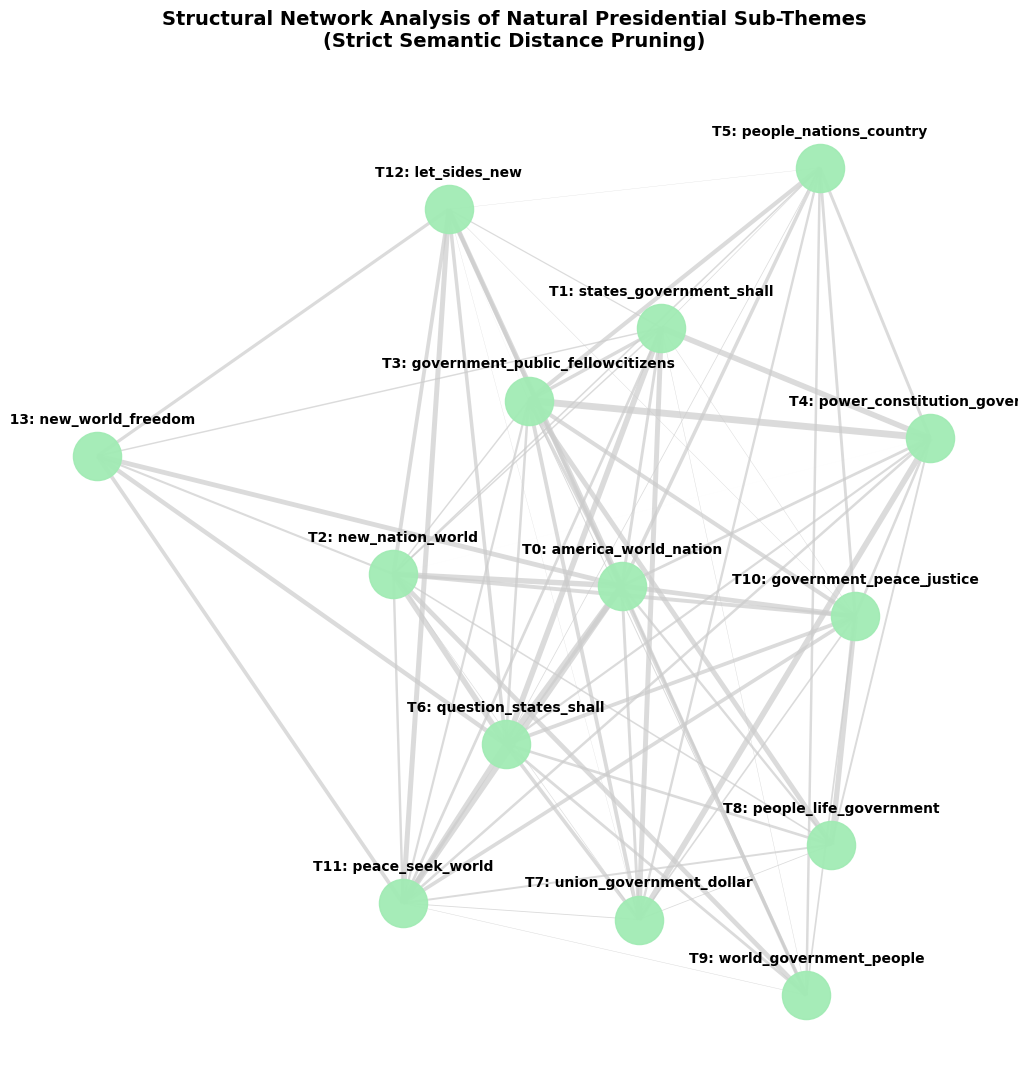

In [87]:
# Showing final network

plt.figure(figsize=(13, 13))
pos = nx.spring_layout(G_final, k=0.9, seed=42)

nx.draw_networkx_nodes(G_final, pos, node_color='#a1ebb4', node_size=1200, alpha=0.95)


if len(G_final.edges()) > 0:
    edge_widths = [(G_final[u][v]['weight'] - similarity_threshold) * 20 for u, v in G_final.edges()]
    nx.draw_networkx_edges(G_final, pos, width=edge_widths, edge_color='#cccccc', alpha=0.7)

pos_labels = {node: (coords[0], coords[1] + 0.05) for node, coords in pos.items()}
nx.draw_networkx_labels(G_final, pos_labels, labels=topic_labels,
                        font_size=10, font_weight='bold', font_family='sans-serif')

plt.title("Structural Network Analysis of Natural Presidential Sub-Themes\n(Strict Semantic Distance Pruning)",
          fontsize=14, pad=25, weight='bold')
plt.axis('off')
plt.show()